## Setup

### Import Libraries

In [1]:
import torch
import torch.nn as nn

from sklearn.datasets import make_moons
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Utility Functions

In [2]:
# Code adapted from this notebook: https://jonchar.net/notebooks/Artificial-Neural-Network-with-Keras/

def plot_decision_boundary(model: nn.Module, X: torch.Tensor, y: torch.Tensor, output: torch.Tensor, device: str):
    """
    Helper function to plot decision boundary

    Args:
    model: model instance
    X: Input data
    y: Class Labels/Targets
    device: "cpu" or "cuda"

    Returns:
    Nothing
    """
    # Transfer the data to the CPU
    X = X.cpu().numpy()
    y = y.cpu().numpy()

    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    h = 0.01

    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict the function value for the whole grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_points = torch.from_numpy(grid_points).type(torch.FloatTensor)
    grid_output = model(grid_points)
    Z = torch.argmax(grid_output, 1)
    Z_grid = Z.reshape(xx.shape)

    # Plot the contour and training examples
    plt.contourf(xx, yy, Z_grid, cmap=plt.cm.Spectral)
    mask = torch.argmax(output, 1) == 0
    plt.plot(X[:,0][mask], X[:,1][mask], 'o', color = 'white', label = 'Label = 0')
    plt.plot(X[:,0][~mask], X[:,1][~mask], 'o', color = 'k', label = 'Label = 1')
    plt.legend()
    #plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.binary)

class utils:
    plot_decision_boundary = plot_decision_boundary

### Generate Data

In [3]:
X, y = make_moons(256, noise=0.1, random_state=42)

df = pd.DataFrame({"x0": X[:,0], "x1": X[:,1], "y": y})

df

,x0,x1,y
0,1.770779,-0.057636,1
1,1.113900,0.154442,0
2,-0.257176,1.014721,0
3,1.371609,-0.580707,1
4,-1.072331,0.318978,0
...,...,...,...
251,-0.959604,0.521036,0
252,1.045807,0.314699,0
253,-0.654584,0.842351,0
254,0.779745,-0.456423,1


#### Convert Data to Tensors

In [4]:
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

#### Plot Generated Data

Simple dataset with two classes. Will be used to study how to make a network that can perform a classification task.

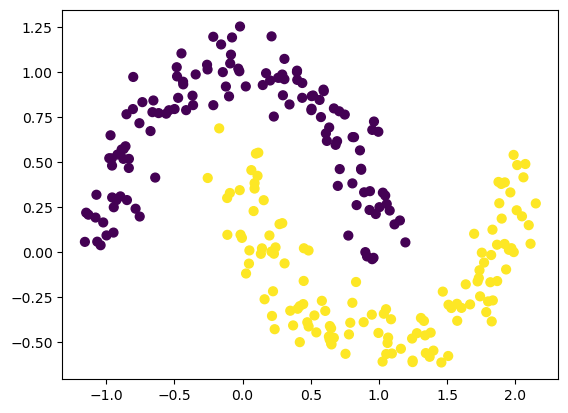

In [5]:
plt.scatter(X[:,0], X[:,1], s = 40, c = y);

## Section 1: Update the Network Parameters

| Code | Description |
| --- | --- |
| `net(X_input)` | Pass input `X_input` to a neuronal network `net`. |
| `y_net = net(X_input)` | Pass input `X_input` to a neuronal network `net` and assign the output to a variable `y_net`. |
| `nn.CrossEntropyLoss()` | Creates a cross-entropy loss function. Used for classification problems.|
| `loss_function = nn.CrossEntropyLoss()` | Creates a cross-entropy loss function and assigns it to a variable named `loss_function`. |
| `loss_function(y_net, y_true)` | Calculates the loss between the output of the network `y_net` and the true y-values from the data `y_true`. |
| `optim.SGD(net.parameters())` | Creates a stochastic gradient descent (GD) optimizer. |
| `optimizer = optim.SGD(net.parameters())` | Creates a stochastic gradient descent (GD) optimizer and assigns it to a variable called `optimizer`. |
| `optimizer.zero_grad()` | Resets the gradients before the next iteration in the optimization. |
| `loss.backward()`| Performs backward propagation and calculates the gradients through the graph leaves (network). |
| `optimizer.step()` | Update the parameters of the network. |


In [6]:
SEED = 42
torch.manual_seed(SEED)

net = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,2)
)

n_samples = 80
X_samples = X[:n_samples]
y_true = y[:n_samples]

**Exercise**: Create a stochastic gradient descent optimizer for the parameters of the network `net`.

In [ ]:
optimizer = torch.optim.SGD(net.parameters())
optimizer

**Exercise**: Create a cross entropy loss function and assign it to a variable called `loss_function`.

In [ ]:
loss_function = nn.CrossEntropyLoss()
loss_function

**Exercise**: Pass the input ``X_samples``  to the network `net` defined in the first cell of the section and assign it to a variable called `y_net`. When you display the output from the network it should look something like this:

**TODO: Update numbers**

tensor([[-0.0750, -0.1321],  <br>
&nbsp;[-0.6765,  0.0395],  <br>
&nbsp;[-0.3084, -0.0583],  <br>
&nbsp;[-0.0244,  0.0879],  <br>
&nbsp;[-0.2079, -0.0272]], grad_fn=``<AddmmBackward0>``)

In [9]:
y_net = net(X_samples)
y_net

tensor([[ 0.2759,  0.3435],
        [ 0.1586,  0.0792],
        [-0.2391, -0.6694],
        [ 0.1299,  0.2777],
        [-0.3268, -0.8778],
        [ 0.0390, -0.0239],
        [ 0.3604,  0.3994],
        [ 0.0031, -0.1932],
        [ 0.1422,  0.0306],
        [ 0.0588, -0.2122],
        [ 0.0713,  0.0273],
        [ 0.2477,  0.3598],
        [ 0.2532,  0.3803],
        [ 0.2137,  0.3237],
        [-0.0886, -0.5380],
        [-0.1392, -0.5129],
        [ 0.1067,  0.1628],
        [ 0.1194, -0.0869],
        [-0.3603, -0.8661],
        [ 0.0874, -0.1151],
        [ 0.3241,  0.3983],
        [ 0.0603, -0.1402],
        [-0.2771, -0.7952],
        [-0.0108, -0.3683],
        [ 0.1129, -0.1096],
        [-0.2680, -0.8102],
        [ 0.3814,  0.3706],
        [ 0.1356,  0.3026],
        [ 0.1291,  0.0139],
        [ 0.0063, -0.2137],
        [ 0.0414,  0.0263],
        [-0.3712, -0.8874],
        [ 0.0029, -0.3173],
        [ 0.0697,  0.1658],
        [ 0.2101,  0.3099],
        [ 0.0602, -0

**Exercise**: Calculate the loss between the output `y_net` produced by the neural net in the cell below and the original y-data `y_true`.

**Hint**: Use the `loss_function` variable you defined above.

In [10]:
loss = loss_function(y_net, y_true)
loss

tensor(0.6271, grad_fn=<NllLossBackward0>)

**Exercise**: Calculate the gradients for the network parameters by performing backward propagation on the loss.

**Hint**: See reference table.

In [11]:
loss.backward()

If you run the cell below after solving the exercise above (and running it), a tensor with two columns of numbers should be displayed. If the exercise was not solved correctly, nothing will be displayed.

In [12]:
next(net.parameters()).grad

tensor([[ 0.0131, -0.0082],
        [-0.0023,  0.0110],
        [-0.0039,  0.0030],
        [ 0.0022, -0.0068],
        [-0.0082,  0.0036],
        [ 0.0852, -0.0566],
        [-0.0295,  0.0195],
        [ 0.0041, -0.0013],
        [-0.0322,  0.0226],
        [ 0.0146, -0.0144],
        [ 0.0466, -0.0523],
        [ 0.0040, -0.0027],
        [ 0.0229, -0.0179],
        [ 0.0000,  0.0000],
        [-0.0031,  0.0009],
        [-0.0562,  0.0249]])

**Exercise**: Now that the gradients have been calculated, you can optimize the parameters of the network using the `.step()` function of the `optimizer`.

In [13]:
optimizer.step()

**Exercise**: Reset the gradients of the network parameters. This needs to be done for the next iteration of the training to avoid accumulation of gradients.

In [14]:
optimizer.zero_grad()

Now run the cell below, which displays the gradients in exactly the same way as above. If you solved the last exercise correctly, nothing should be displayed this time. Why is that, do you think?

In [15]:
next(net.parameters()).grad

**Exercise**: Putting it all together: Fill in the relevant code from the exercises above under the comments in the cells below. These are the fundamental steps in training a neural network.

In [16]:
# 1. Create a stochastic gradient descent optimizer and assign it to a variable named "optimizer"

# 2. Create a cross-entropy loss function and assign to variable named "loss_function"

In [ ]:
'''The following steps will be performed iteratively during training'''

# 3. Reset the gradients of the optimizer

# 4. Pass the X_samples to the net and assign the output to a variable called "y_net"

# 5. Calculate the loss between the output from the model y_net and the true y-values from the data y_true using the loss function defined in step 2

# 6. Do backpropagation on the loss to calculate the gradients

# 7. Update the network parameters


'The following steps will be performed iteratively during training'

## Section 2: For Loops

When training a neural network, we would like to go through many iterations of passing the input to the network, comparing the network's output to the true values from the dataset, and updating the parameters of the network. To do that, we use a for loop, which allows us to perfor the same set of operations a predefined number of times.

| Code | Description |
| --- | --- |
| `for letter in ["a", "b", "c"]:` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(letter)` | Print every `letter` in the list `["a", "b", "c"]`|
| `for i in range(5):` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(i)` | Print every number `i` between 0 and 5 (not including 5)|
| `for i in range(2, 7):` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(i)` | Print every number `i` between 2 and 7 (not including 7)|
| `for i in range(1, 10, 2):` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(i)` | Print every **second** number `i` between 1 and 10 (not including 10)|
| `for x_i in x:` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(x_i)` | Print every element `x_i` in the collection `x`|
| `for x_i in x:` <br> &nbsp;&nbsp;&nbsp;&nbsp; `for y_i in y`: <br> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; `print(x_i, y_i)` | Print every element `x_i` and `y_i` in the collections `x` and `y`|
| `new_list = []` or `new_list = list()`| Initialize an empty list named `new_list` |
| `new_list.append(element)`| Append an element to the list `new_list` |

#### **Exercises**

**Example**: Write a for loop that prints the numbers **0** to **9**.

In [ ]:
for num in range(9):
    print(num)

0
1
2
3
4
5
6
7
8


**Exercise**: Write a for loop that prints the numbers **5** to **10**.


In [19]:
for i in range(5,10):
    print(i)

5
6
7
8
9


**Exercise**: Write a for loop that counts from **0** to **100** in steps of **10**.

In [20]:
for j in range(0,100,10):
    print(j)

0
10
20
30
40
50
60
70
80
90


**Exercise**: Use a loop to print all `fruits` and `colors`, for example `banana is yellow"`.

In [21]:
# provided

fruits = ["banana", "orange", "cherry"]
colors= ["yellow", "orange", "green"];

In [22]:
for fruit in fruits:
    for color in colors:
        print(fruit+' is '+color)

banana is yellow
banana is orange
banana is green
orange is yellow
orange is orange
orange is green
cherry is yellow
cherry is orange
cherry is green


**Exercise**: Write a loop that calculates the square of each element in `numbers` and stores the result in a new list called `squared_numbers`. Display the `squared_numbers` list at the end to check that it is correct.

In [23]:
numbers = [4, 6, 12, 50]

squared_numbers = []

for i in range(len(numbers)):
    num_squared = numbers[i]**2
    squared_numbers.append(num_squared)

squared_numbers

[16, 36, 144, 2500]

**Exercise**: Write a loop that multiplies each element in the list `numbers` by 4 and store the results in a new list called `multiplied_numbers`. Display `multiplied_numbers` to check that it is correct.

In [24]:
numbers = [4, 6, 12, 50]

multiplied_numbers = []
for num in numbers:
    mult_number = 4*num

    multiplied_numbers.append(mult_number)

multiplied_numbers

[16, 24, 48, 200]

## Section 3: Train the Network Iteratively

| Code | Description |
| --- | --- |
| `loss_function(y_net, y_true)` | Calculates the loss between the output of the network `y_net` and the true y-values from the data `y_true`. |
| `loss_function(y_net, y_true).item()` | Extracts the loss value (the number alone as a ``float`` and not as a ``tensor`` type). |
| `optim.SGD(net.parameters())` | Creates a stochastic gradient descent (SGD) optimizer. |
| `optimizer = optim.SGD(net.parameters())` | Creates a stochastic gradient descent (SGD) optimizer and assigns it to a variable called `optimizer`. |
| `optimizer.zero_grad()` | Resets the gradients before the next iteration in the optimization. |
| `loss.backward()`| Performs backward propagation and calculates the gradients through the graph leaves (network). |
| `optimizer.step()` | Update the parameters of the network. |

#### **Exercises**

In [26]:
SEED = 42
torch.manual_seed(SEED)

net = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,2)
)

n_samples = 80
X_samples = X[:n_samples]
y_true = y[:n_samples]

**Example**: Use a loop to pass the input `X_samples` to the network five times and calculate the loss between the output `y_net` and the true y-values `y_true` each time. Store the loss in each iteration in a list `losses`.

In [ ]:
# create stochastic gradient descent optimizer
optimizer = torch.optim.SGD(net.parameters())

# create loss function
loss_function = nn.CrossEntropyLoss()

# create empty list to store loss calculated in each epoch
losses = []

n_epochs = 5
for epoch in range(n_epochs):
    # pass the input to the network
    y_net = net(X_samples)

    # calculate the loss
    loss = loss_function(y_net, y_true)

    # store the value of the loss in a list
    losses.append(loss.item())

    print(f"Epoch nr. {epoch}, loss = {loss.item()}")

Epoch nr. 0, loss = 0.6271013021469116
Epoch nr. 1, loss = 0.6271013021469116
Epoch nr. 2, loss = 0.6271013021469116
Epoch nr. 3, loss = 0.6271013021469116
Epoch nr. 4, loss = 0.6271013021469116


[0.6271013021469116,
 0.6271013021469116,
 0.6271013021469116,
 0.6271013021469116,
 0.6271013021469116]

The loss was the same in each iteration in the exercise above because the parameters wasn't updated in each iteration, so naturally, the result was always the same.

**Exercise**: Fill in the blanks (``__``) in the code cell below to update the parameters of the network in each iteration.

In [ ]:
# create stochastic gradient descent optimizer
optimizer = ___

# create loss function
loss_function = nn.CrossEntropyLoss()

# create empty list to store loss calculated in each epoch
losses = []

n_epochs = 5
for epoch in range(n_epochs):
    # reset the gradients
    ___
    
    # pass the input to the network
    y_net = net(X_samples)

    # calculate the loss
    loss = loss_function(y_net, y_true)

    # store the value of the loss in a list
    losses.append(loss.item())

    # perform backward propagation to calculate the gradients
    loss.backward()

    # update the parameters
    ___

    print(f"Epoch nr. {epoch}, loss = {loss.item()}")

Epoch nr. 0, loss = 0.6271013021469116
Epoch nr. 1, loss = 0.6271013021469116
Epoch nr. 2, loss = 0.6271013021469116
Epoch nr. 3, loss = 0.6271013021469116
Epoch nr. 4, loss = 0.6271013021469116


In [ ]:
# create stochastic gradient descent optimizer
optimizer = torch.optim.SGD(net.parameters())

# create loss function
loss_function = nn.CrossEntropyLoss()

# create empty list to store loss calculated in each epoch
losses = []

n_epochs = 5
for epoch in range(n_epochs):
    # reset the gradients
    optimizer.zero_grad()
    
    # pass the input to the network
    y_net = net(X_samples)

    # calculate the loss
    loss = loss_function(y_net, y_true)

    # store the value of the loss in a list
    losses.append(loss.item())

    # perform backward propagation to calculate the gradients
    loss.backward()

    # update the parameters
    optimizer.step()

    print(f"Epoch nr. {epoch}, loss = {loss.item()}")

Epoch nr. 0, loss = 0.5031144618988037
Epoch nr. 1, loss = 0.5029700994491577
Epoch nr. 2, loss = 0.5028259754180908
Epoch nr. 3, loss = 0.5026820302009583
Epoch nr. 4, loss = 0.50253826379776


**Exercise**: Did the loss change in each iteration this time? How much? If it was only by a very little, you can try to change the learning rate by setting the ``lr`` parameter in the stochastic gradient descent optimizer to 0.1 (`lr = 0.1`) and run it again.

In [ ]:
# create stochastic gradient descent optimizer
optimizer = torch.optim.SGD(net.parameters(), lr=0.1)

# create loss function
loss_function = nn.CrossEntropyLoss()

# create empty list to store loss calculated in each epoch
losses = []

n_epochs = 5
for epoch in range(n_epochs):
    # reset the gradients
    optimizer.zero_grad()
    
    # pass the input to the network
    y_net = net(X_samples)

    # calculate the loss
    loss = loss_function(y_net, y_true)

    # store the value of the loss in a list
    losses.append(loss.item())

    # perform backward propagation to calculate the gradients
    loss.backward()

    # update the parameters
    optimizer.step()

    print(f"Epoch nr. {epoch}, loss = {loss.item()}")

Epoch nr. 0, loss = 0.5023946166038513
Epoch nr. 1, loss = 0.4884633421897888
Epoch nr. 2, loss = 0.4760373532772064
Epoch nr. 3, loss = 0.46483510732650757
Epoch nr. 4, loss = 0.45467013120651245


**Exercise**: Plot the losses stored from each epoch.

In [1]:
plt.plot(losses)

NameError: name 'plt' is not defined

## Section 4: 